<a href="https://colab.research.google.com/github/KHADAR134/Early-Stage-Diabetes-Risk-Prediction-Using-Symptom-Based-Machine-Learning./blob/main/ESD_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Early-Stage Diabetes Risk Prediction Using Symptom-Based Machine Learning.**

# **Importing Libraries and Loading the Dataset**
In this cell, I import the necessary libraries for data manipulation and visualization. I then read the dataset and inspect its structure.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Dataset 1 _ Pima Indians diabetes dataset (PIDD).xlsx'
df = pd.read_excel(file_path)

# Display the first few rows and summary information
print("Dataset Head:")
df.head()


Dataset Head:


,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


In [24]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 768 non-null    int64  
 1   Glucose                     768 non-null    int64  
 2   Blood pressure              768 non-null    int64  
 3   Skin thickness              768 non-null    int64  
 4   Insulin                     768 non-null    int64  
 5   Body mass index             768 non-null    float64
 6   Diabetes pedigree function  768 non-null    float64
 7   Age                         768 non-null    int64  
 8   Outcome                     768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


# **Data Preprocessing**
The dataset contains '0' values in columns like Glucose, Blood Pressure, etc., which are physically impossible. I will replace these zeros with NaN and then impute them with the median values of their respective columns. I also check for duplicate entries.

In [25]:
# Create a copy for cleaning
df_cleaned = df.copy()

# Identify columns where 0 is a missing value (except Pregnancies and Outcome)
cols_with_missing = ['Glucose', 'Blood pressure', 'Skin thickness', 'Insulin', 'Body mass index']

# Replace 0 with NaN
df_cleaned[cols_with_missing] = df_cleaned[cols_with_missing].replace(0, np.nan)

# Impute missing values with the median of each column
for col in cols_with_missing:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Check for duplicates
print(f"Number of duplicate rows: {df_cleaned.duplicated().sum()}")

# Summary of the cleaned data
print("\nCleaned Data Summary:")
df_cleaned.describe()

Number of duplicate rows: 0

Cleaned Data Summary:


,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


# **EDA**

## **Statistical Distribution (Histograms)**
To understand how each feature is distributed across the dataset, I will plot histograms for all variables. This helps in identifying the skewness and range of the data.

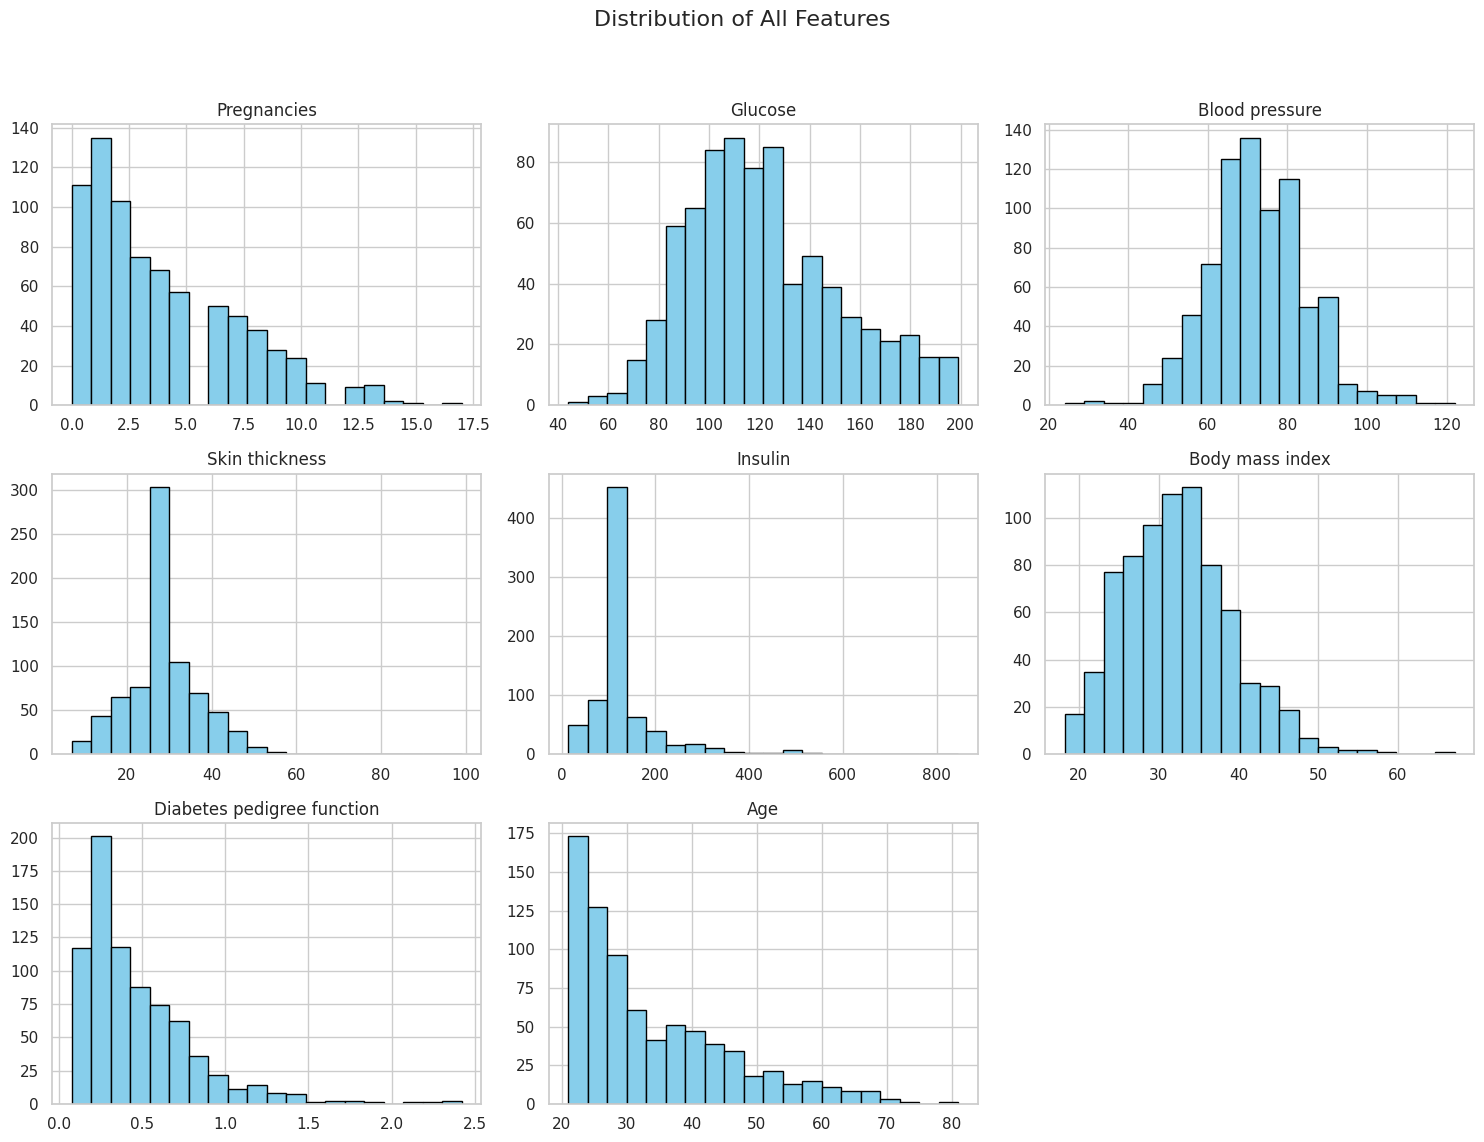

In [26]:
# Plotting histograms for all features
sns.set(style="whitegrid")
df_cleaned.hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of All Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##**Correlation Analysis (Heatmap)**
Understanding the correlation between different features and the target variable (Outcome) is crucial. I use a heatmap to visualize the linear relationships.

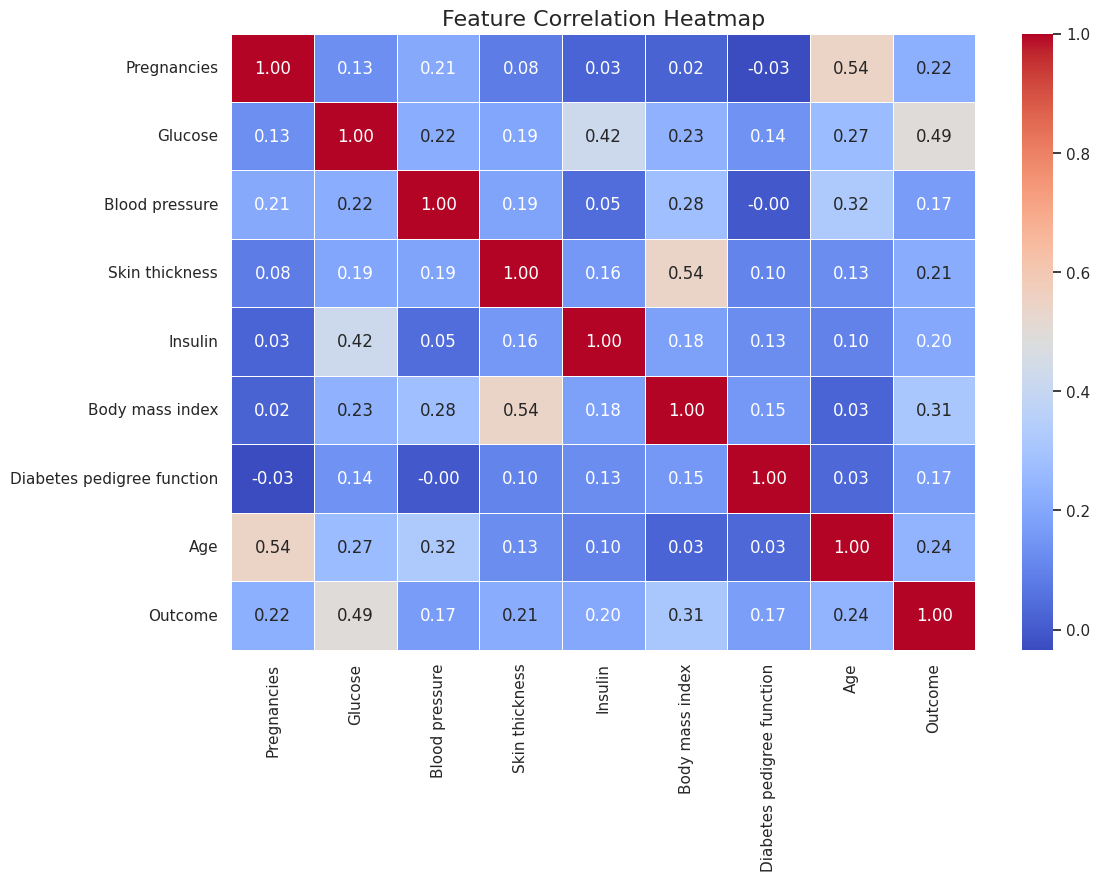

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Outcome' column to numeric values (0 and 1) for correlation calculation
df_cleaned['Outcome'] = df_cleaned['Outcome'].map({'tested_negative': 0, 'tested_positive': 1})

# Plotting the Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

## **Relationship Between Features and Outcome (Boxplots)**
Finally, I use boxplots to see how different feature values differ between patients with diabetes (Outcome=1) and those without (Outcome=0). This reveals which factors are most distinct for diabetic patients.

/tmp/ipykernel_21195/3614724107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df_cleaned, palette='Set2')
/tmp/ipykernel_21195/3614724107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df_cleaned, palette='Set2')
/tmp/ipykernel_21195/3614724107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df_cleaned, palette='Set2')
/tmp/ipykernel_21195/3614724107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

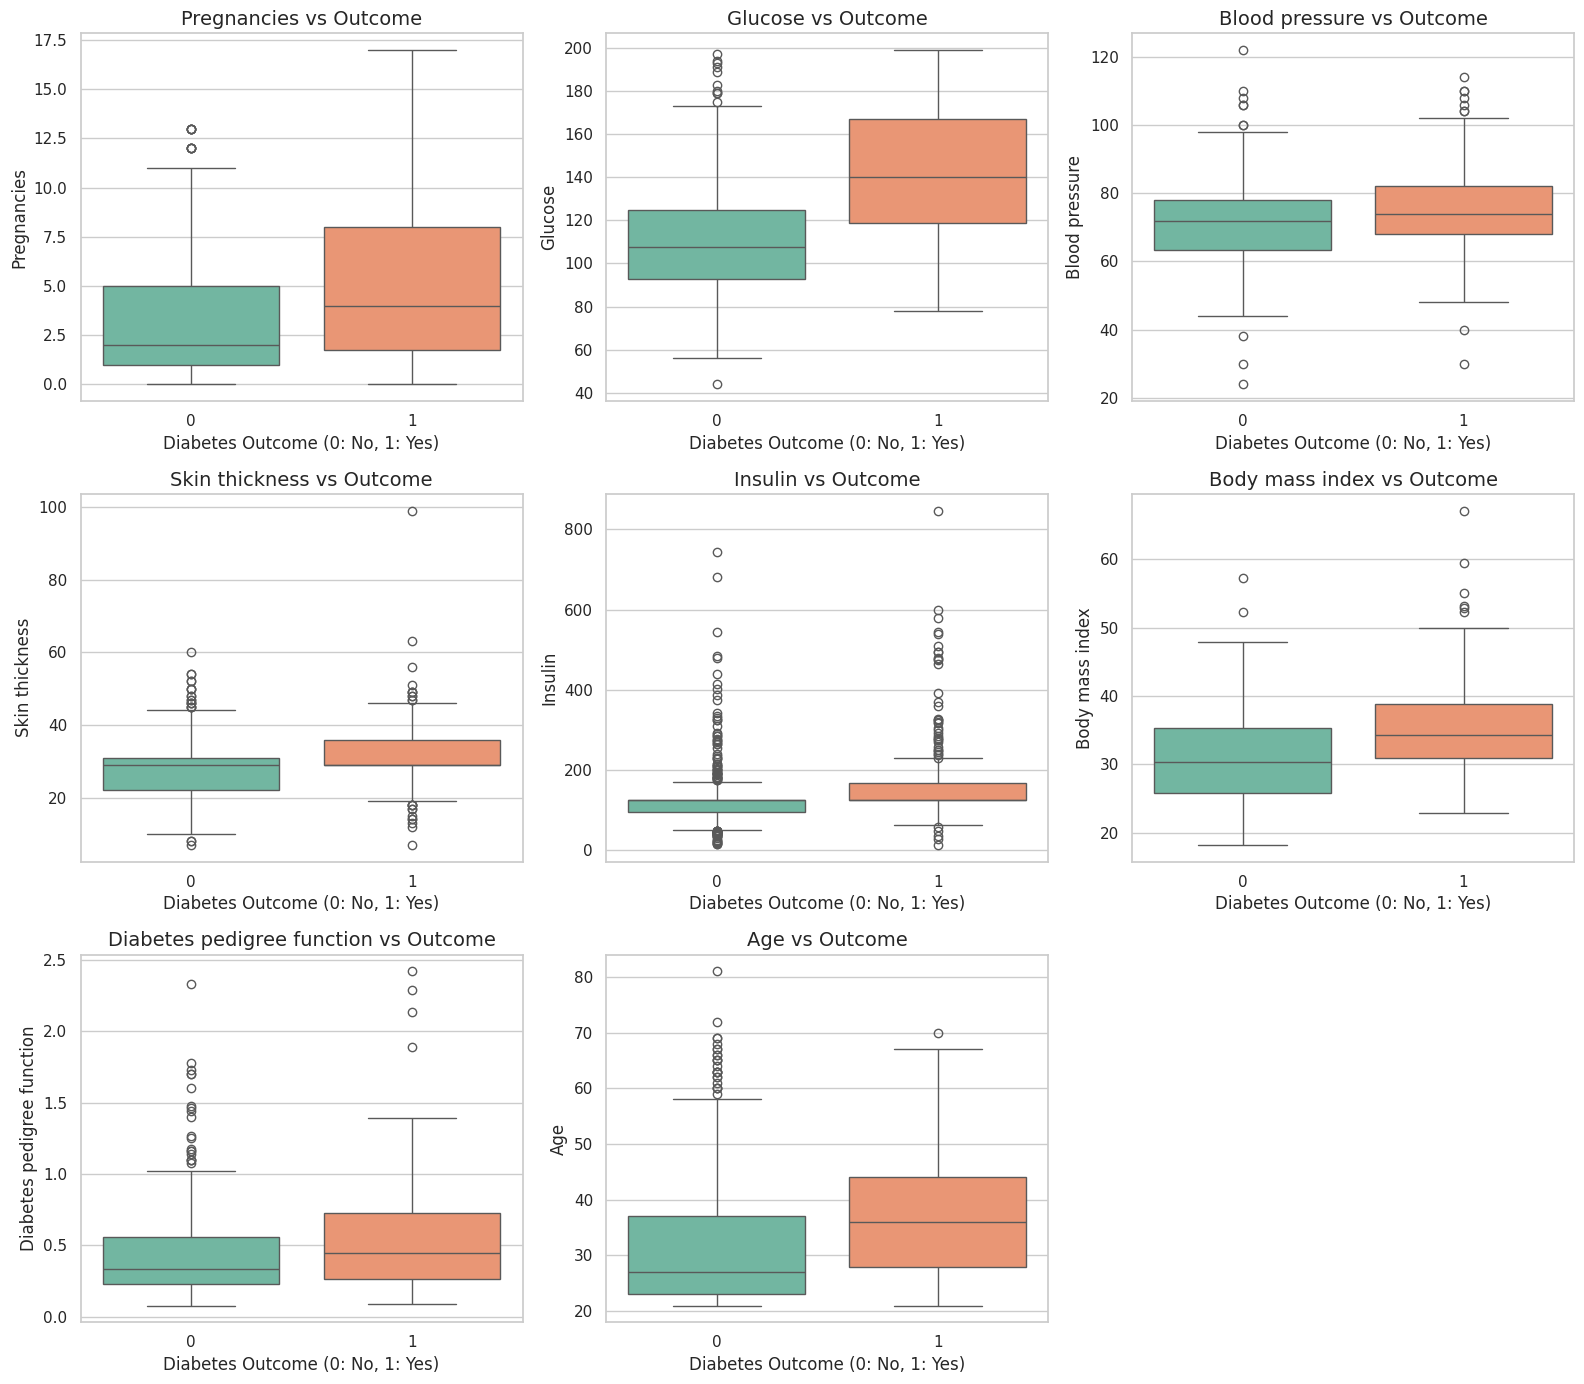

In [28]:
# Plotting Boxplots for each feature against the Outcome
features = df_cleaned.columns[:-1] # All columns except Outcome
plt.figure(figsize=(16, 14))

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='Outcome', y=col, data=df_cleaned, palette='Set2')
    plt.title(f'{col} vs Outcome', fontsize=14)
    plt.xlabel('Diabetes Outcome (0: No, 1: Yes)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## **Class Distribution Plot**
In this step, I create a count plot to show the number of instances for each class in the Outcome column.

/tmp/ipykernel_21195/2168185407.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df_cleaned, palette='viridis')


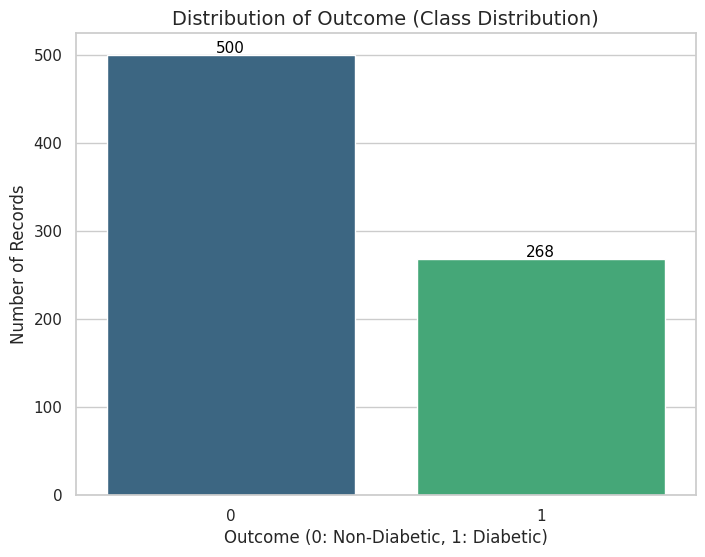

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Class Distribution (Outcome)
plt.figure(figsize=(8, 6))
sns.countplot(x='Outcome', data=df_cleaned, palette='viridis')

# Adding descriptive titles and labels
plt.title('Distribution of Outcome (Class Distribution)', fontsize=14)
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

# Adding the exact count labels on top of the bars for clarity
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

# **Splitting the Dataset**
I split the data into a training set (to train the model) and a testing set (to evaluate its performance on unseen data). We use an 80/20 split and ensure the class proportions are maintained using stratify.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_cleaned.drop('Outcome', axis=1)
y = df_cleaned['Outcome']

# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling: Standardize the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 614 samples
Testing set size: 154 samples


# **Training Multiple Models**
I will train three distinct models: Logistic Regression, Random Forest, and Support Vector Machine (SVM). I will then evaluate them using standard metrics and compare their ROC curves.

In [31]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import time

# Update the models dictionary
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machines": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score



--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154


--- Support Vector Machines Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                     

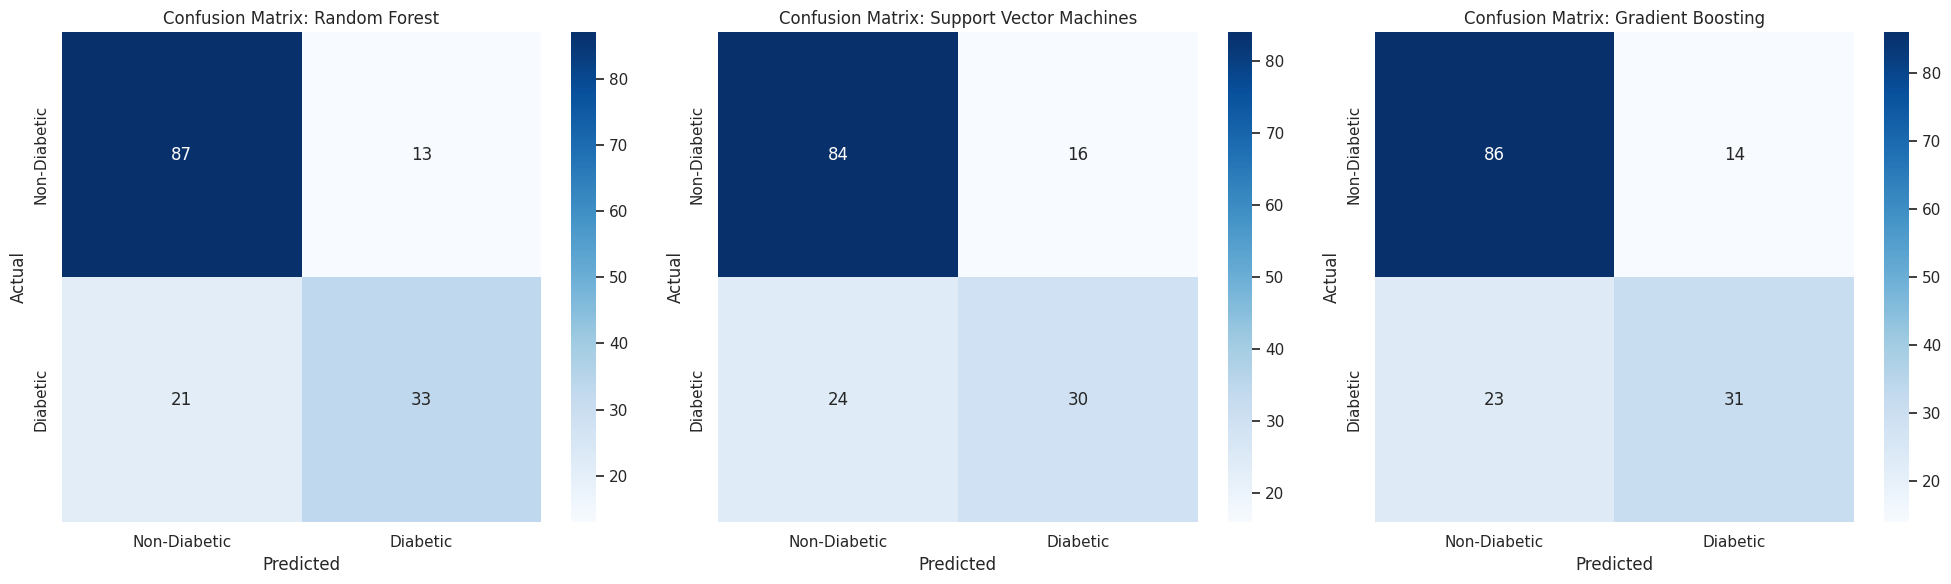


--- Model Timing and Overall Accuracy ---
                     Model  Train Time (s)  Test Time (s)  Accuracy  \
0            Random Forest         0.22382        0.01084    0.7792   
1  Support Vector Machines         0.05359        0.00328    0.7403   
2        Gradient Boosting         0.23694        0.00101    0.7597   

   Precision  Recall  F1-Score  
0     0.7174  0.6111    0.6600  
1     0.6522  0.5556    0.6000  
2     0.6889  0.5741    0.6263  


In [32]:
import time
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store timing and performance metrics
performance_metrics = []
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(models.items()):
    # Measure Training Time
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()
    train_duration = end_train - start_train

    # Measure Testing Time
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    end_test = time.time()
    test_duration = end_test - start_test

    # Record results
    performance_metrics.append({
        "Model": name,
        "Train Time (s)": round(train_duration, 5),
        "Test Time (s)": round(test_duration, 5),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4)
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Diabetic', 'Diabetic'],
                yticklabels=['Non-Diabetic', 'Diabetic'])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    # Print Classification Report in the console
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

plt.tight_layout()
plt.show()

# Display Timing and Accuracy Table
perf_df = pd.DataFrame(performance_metrics)
print("\n--- Model Timing and Overall Accuracy ---")
print(perf_df)

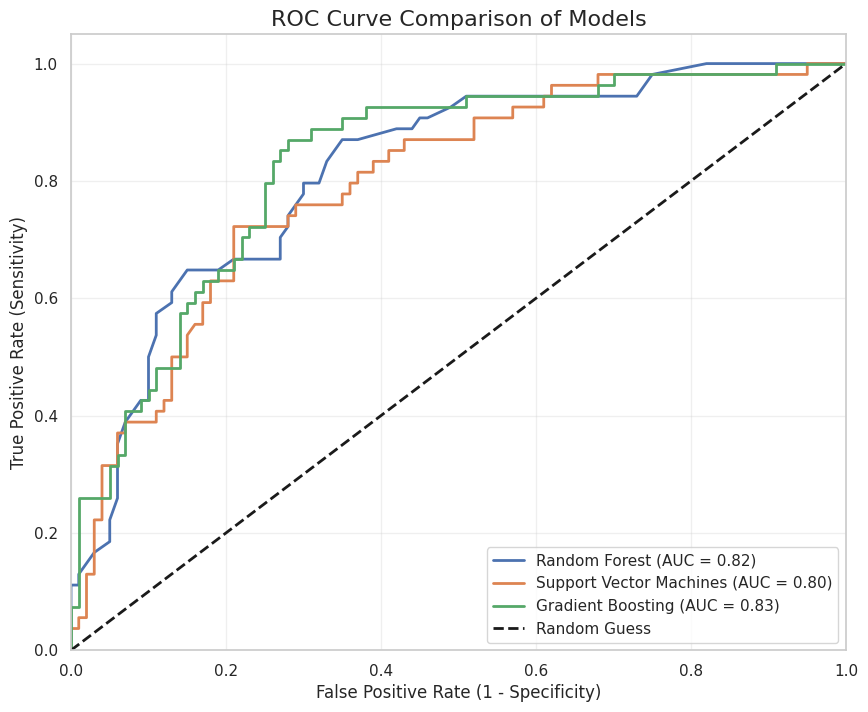

In [33]:
plt.figure(figsize=(10, 8))

# Plotting ROC curve for each model
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', lw=2)

# Plotting the diagonal line for a random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

# Final plot adjustments
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison of Models', fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Applying Balancing (Oversampling) and Visualizing the Distribution**
In this step, wI balance the training dataset and plot a comparison of the class distribution before and after the balancing process. This ensures the model learns equally from both diabetic and non-diabetic cases.

--- Class Distribution ---
Before Balancing:
Class 0 (Non-Diabetic): 400
Class 1 (Diabetic): 214

After Balancing:
Class 0 (Non-Diabetic): 400
Class 1 (Diabetic): 400


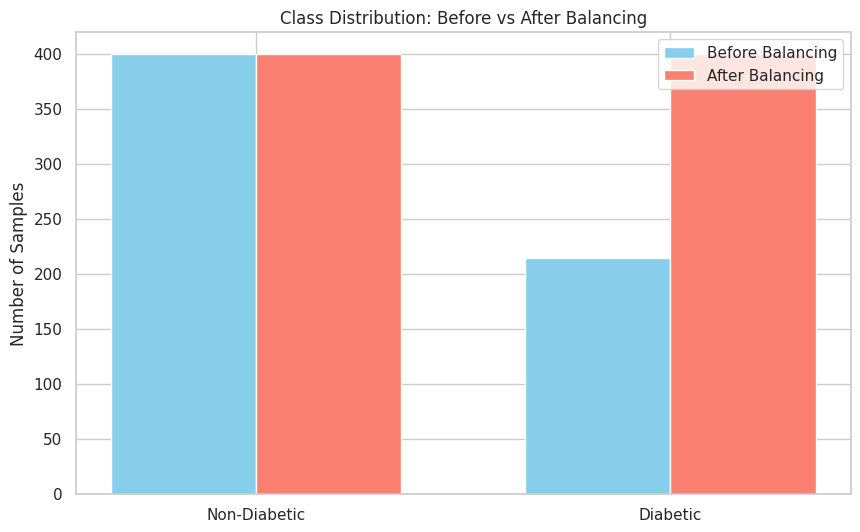

In [34]:
from sklearn.utils import resample
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Combine training features and labels to resample together
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Record counts before balancing
counts_before = y_train.value_counts()

# 3. Separate the majority and minority classes
df_majority = train_data[train_data.Outcome == 0]
df_minority = train_data[train_data.Outcome == 1]

# 4. Upsample the minority class to match the size of the majority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # Sample with replacement
                                 n_samples=len(df_majority),    # Match majority count
                                 random_state=42)

# 5. Combine the balanced data
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# 6. Split back into features and targets
X_train_bal = df_balanced.drop('Outcome', axis=1)
y_train_bal = df_balanced['Outcome']

# 7. Record counts after balancing
counts_after = y_train_bal.value_counts()

# 8. Scale the balanced training data
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)

# 9. Print the statistical results
print("--- Class Distribution ---")
print(f"Before Balancing:")
print(f"Class 0 (Non-Diabetic): {counts_before[0]}")
print(f"Class 1 (Diabetic): {counts_before[1]}")
print(f"\nAfter Balancing:")
print(f"Class 0 (Non-Diabetic): {counts_after[0]}")
print(f"Class 1 (Diabetic): {counts_after[1]}")

# 10. Plotting the Distribution Comparison
plt.figure(figsize=(10, 6))
labels = ['Non-Diabetic', 'Diabetic']
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, [counts_before[0], counts_before[1]], width, label='Before Balancing', color='skyblue')
plt.bar(x + width/2, [counts_after[0], counts_after[1]], width, label='After Balancing', color='salmon')

plt.ylabel('Number of Samples')
plt.title('Class Distribution: Before vs After Balancing')
plt.xticks(x, labels)
plt.legend()
plt.show()

## **Integrated Training and Evaluation on Balanced Data**
This cell handles the entire pipeline: training the three models on the balanced data, measuring performance and timing, generating individual confusion matrices, and plotting a comparative ROC curve.


--- Random Forest Classification Report (Balanced Training) ---
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       100
           1       0.62      0.63      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154


--- Support Vector Machines Classification Report (Balanced Training) ---
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154


--- Gradient Boosting Classification Report (Balanced Training) ---
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       100
           1       0.58     

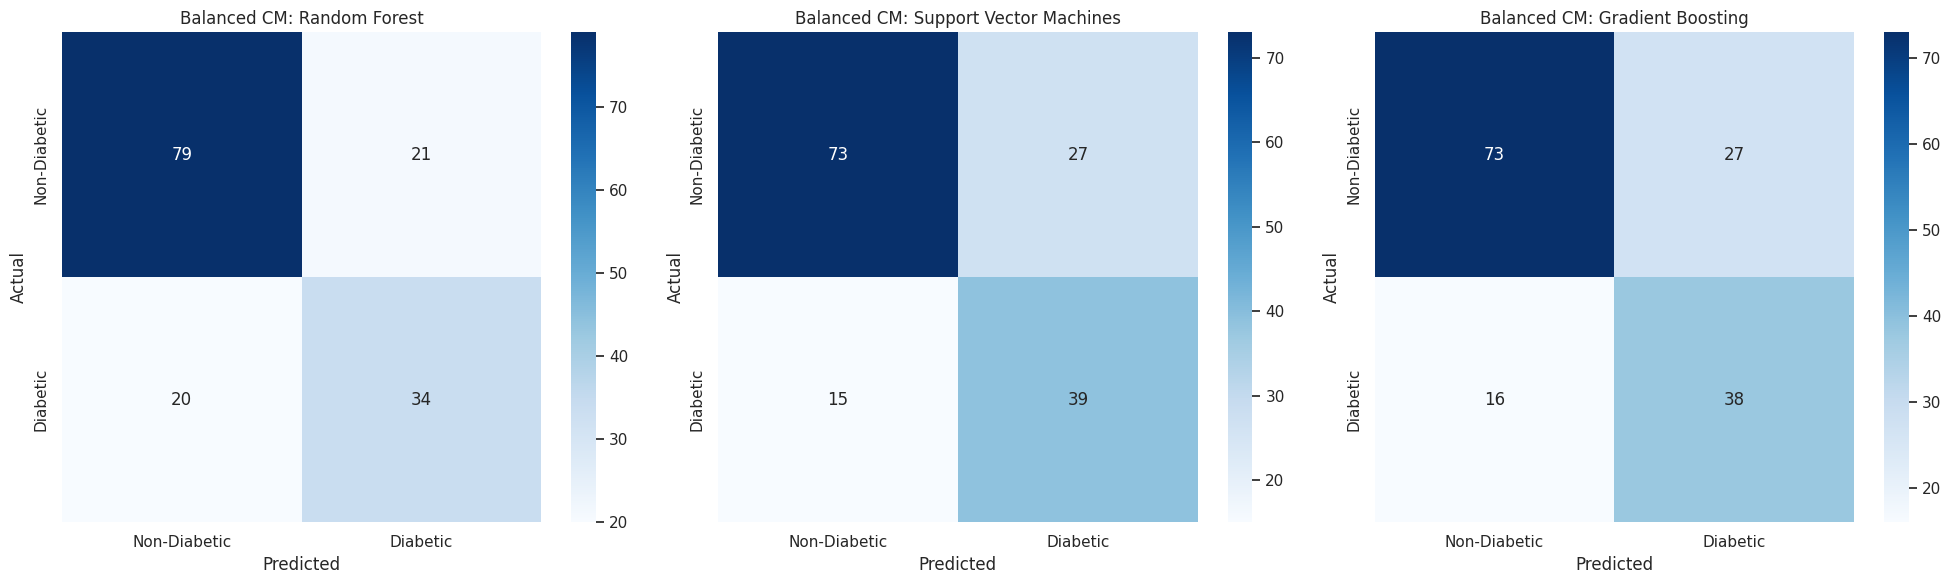


--- Balanced Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Train Time (s),Test Time (s)
0,Random Forest,0.7338,0.6182,0.6296,0.6239,0.7918,0.23850,0.01871
1,Support Vector Machines,0.7273,0.5909,0.7222,0.6500,0.8217,0.09100,0.00816
2,Gradient Boosting,0.7208,0.5846,0.7037,0.6387,0.8028,0.25298,0.00184


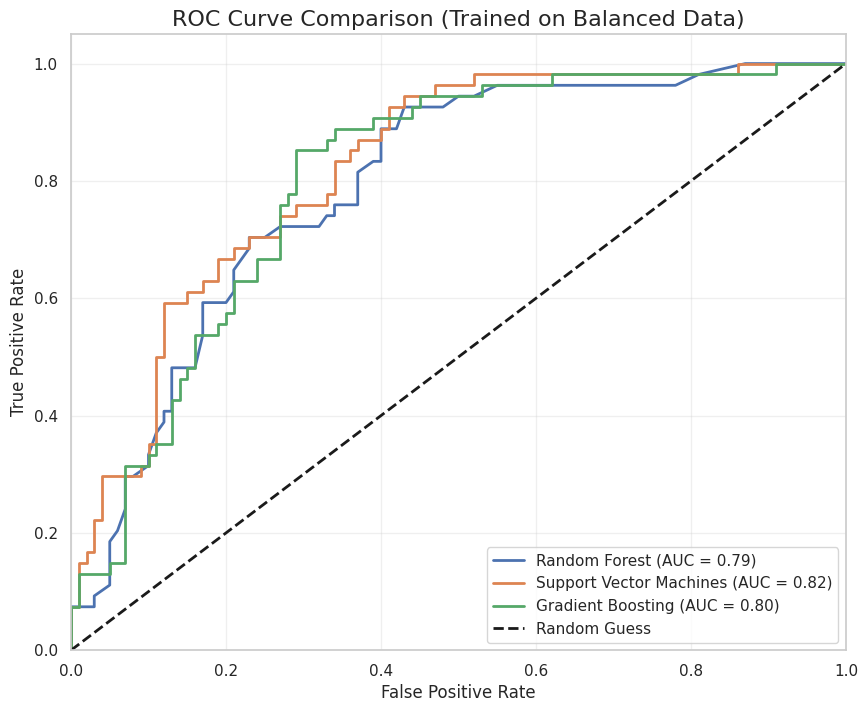

In [35]:
import time
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Dictionary to store performance metrics
performance_metrics = []
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
roc_curves = {}

# Iterate through the models
for i, (name, model) in enumerate(models.items()):
    # 1. Measure Training Time using the BALANCED training set
    start_train = time.time()
    model.fit(X_train_bal_scaled, y_train_bal)
    train_duration = time.time() - start_train

    # 2. Measure Testing Time using the original SCALED test set
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    test_duration = time.time() - start_test

    # 3. Calculate Performance Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Store results for the table
    performance_metrics.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(roc_auc, 4),
        "Train Time (s)": round(train_duration, 5),
        "Test Time (s)": round(test_duration, 5)
    })

    # Store ROC data for plotting
    roc_curves[name] = (fpr, tpr, roc_auc)

    # 4. Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Diabetic', 'Diabetic'],
                yticklabels=['Non-Diabetic', 'Diabetic'])
    axes[i].set_title(f'Balanced CM: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    # Print Classification Report to console
    print(f"\n--- {name} Classification Report (Balanced Training) ---")
    print(classification_report(y_test, y_pred))

plt.tight_layout()
plt.show()

# 5. Display the Comprehensive Performance Comparison Table
perf_df = pd.DataFrame(performance_metrics)
print("\n--- Balanced Model Performance Comparison ---")
display(perf_df)

# 6. Plot ROC Curve Comparison for all models
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison (Trained on Balanced Data)', fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Hyperparameter Tuning with Grid Search**
In this step, i defined a search grid for Random Forest, SVM, and Gradient Boosting. We specifically set the scoring metric to recall to ensure that the chosen parameters prioritize finding positive cases.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import time

# Define the models and the parameter grids
param_grids = {
    "Random Forest": {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    "Support Vector Machines": {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    "Gradient Boosting": {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5]
        }
    }
}

best_models = {}
for name, config in param_grids.items():
    print(f"Searching best parameters for {name}...")
    # Scoring is set to 'recall' to prioritize finding positive cases
    gs = GridSearchCV(config['model'], config['params'], cv=5, scoring='recall', n_jobs=-1)
    gs.fit(X_train_bal_scaled, y_train_bal)
    best_models[name] = gs.best_estimator_
    print(f"Best parameters for {name}: {gs.best_params_}")

Searching best parameters for Random Forest...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Searching best parameters for Support Vector Machines...
Best parameters for Support Vector Machines: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Searching best parameters for Gradient Boosting...
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


## **Model Evaluation with Optimized Parameters**
In this cell, we evaluate our optimized models on the test set using multiple performance metrics (Accuracy, Precision, Recall, F1-Score, and AUC).

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

performance_results = []

for name, model in best_models.items():
    # Performance timing
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    test_time = time.time() - start_test

    # Calculate Metrics
    roc_auc = auc(*roc_curve(y_test, y_proba)[:2])

    performance_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC": round(roc_auc, 4),
        "Test Time (s)": round(test_time, 5)
    })

# Display the summary table
summary_df = pd.DataFrame(performance_results)
print("\n--- Final Performance of Optimized Models (Balanced Data) ---")
display(summary_df)


--- Final Performance of Optimized Models (Balanced Data) ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Test Time (s)
0,Random Forest,0.7468,0.6190,0.7222,0.6667,0.8104,0.04132
1,Support Vector Machines,0.7273,0.5909,0.7222,0.6500,0.8217,0.00832
2,Gradient Boosting,0.7403,0.6129,0.7037,0.6552,0.7896,0.00320


## **Visualizing Confusion Matrices and ROC Curves**
Finally, we generate visual reports to see how the optimized models perform across different classes and thresholds.

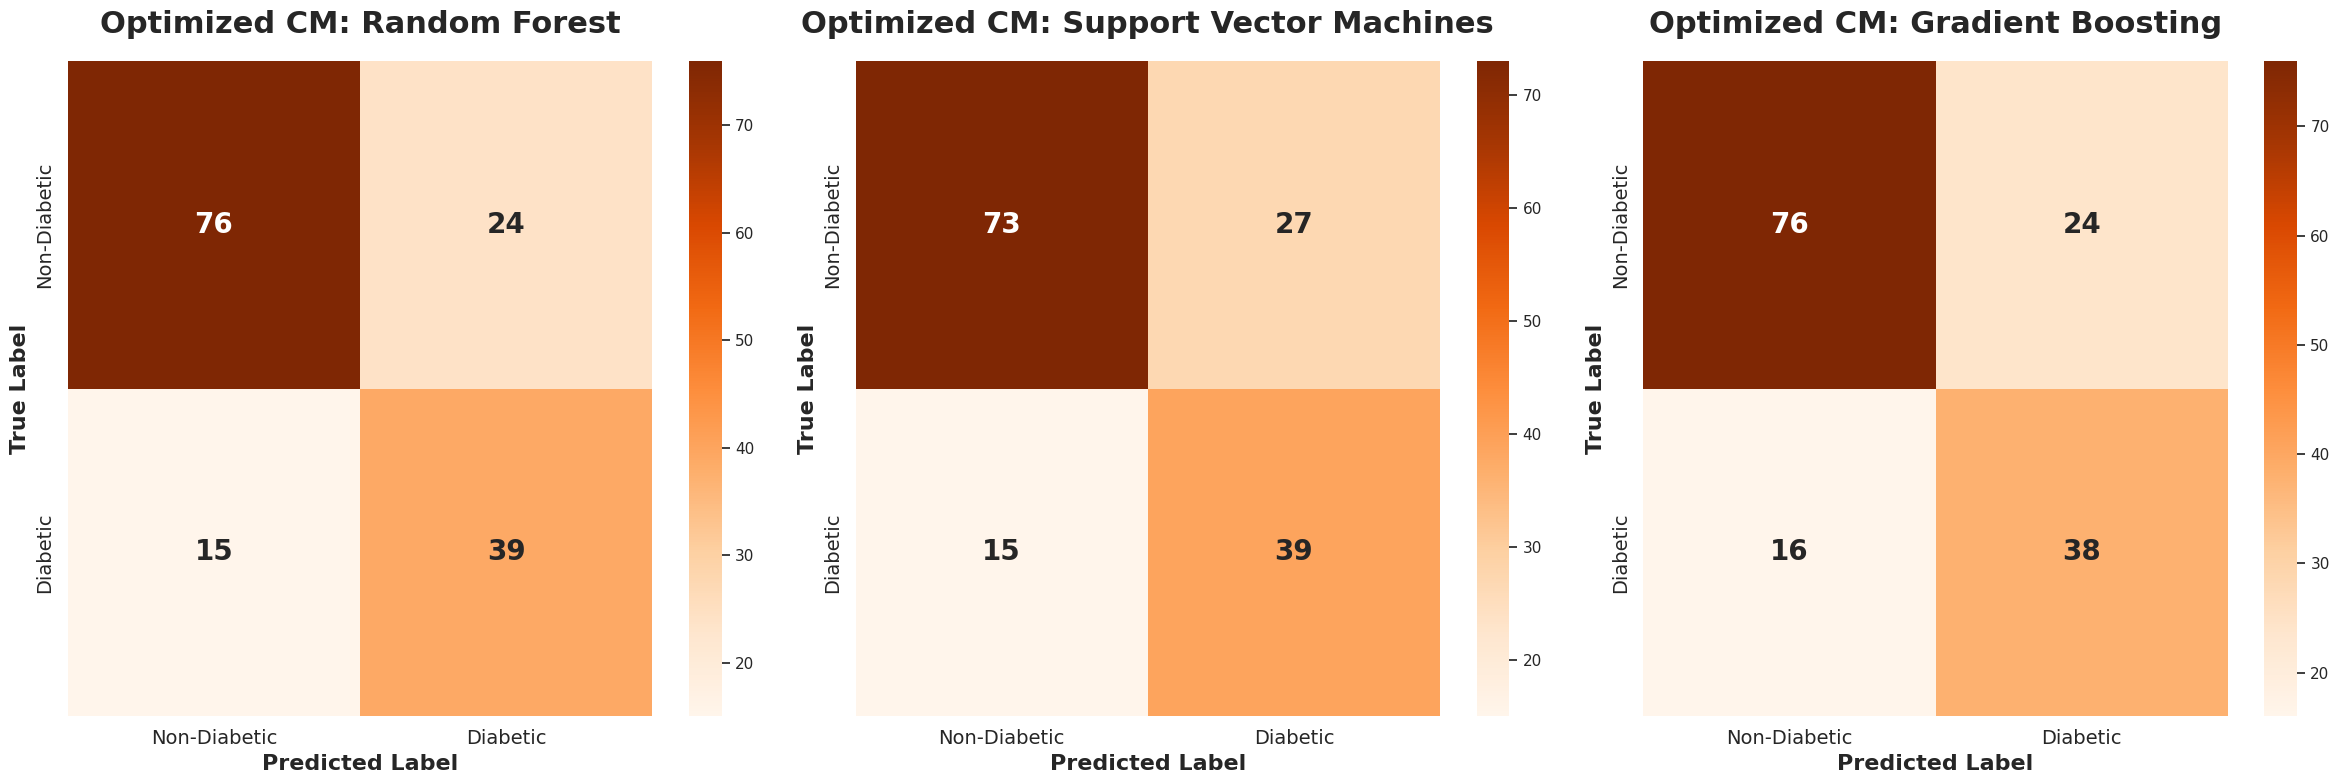

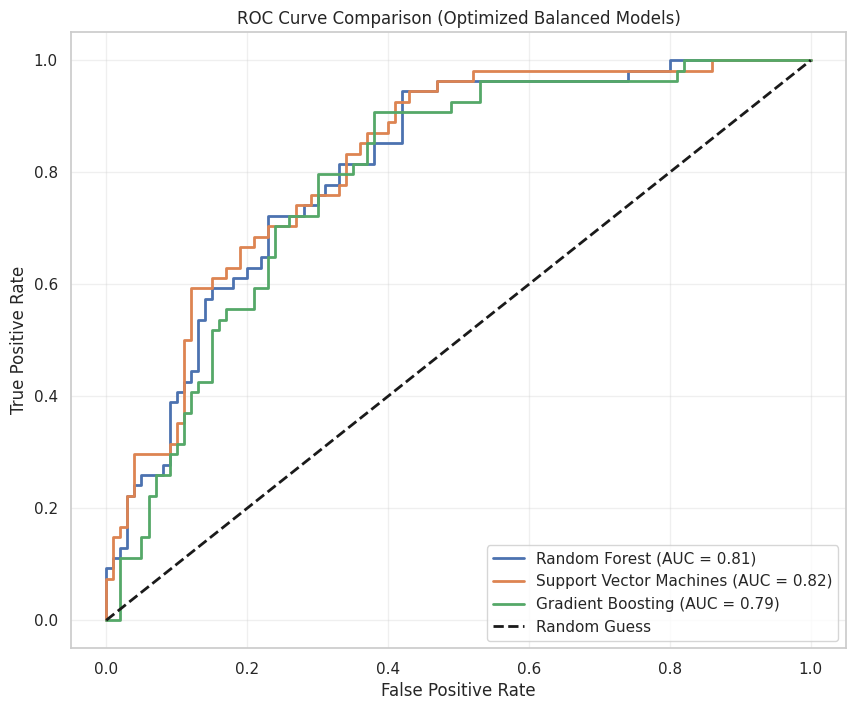

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create a figure to hold the three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (name, model) in enumerate(best_models.items()):
    # Predict using the optimized model
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    # Plotting with Enhanced Font Size and Bold Text
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=['Non-Diabetic', 'Diabetic'],
                yticklabels=['Non-Diabetic', 'Diabetic'],
                # Increased font size to 20 and set weight to 'bold' for cell text
                annot_kws={'size': 20, 'weight': 'bold'})

    # Customizing Titles and Labels
    axes[i].set_title(f'Optimized CM: {name}', fontsize=22, fontweight='bold', pad=20)
    axes[i].set_xlabel('Predicted Label', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('True Label', fontsize=16, fontweight='bold')

    # Increasing size of axis tick labels (Non-Diabetic / Diabetic)
    axes[i].tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

# Plot ROC Curve Comparison
plt.figure(figsize=(10, 8))
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Optimized Balanced Models)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Cross-Validation on Balanced Training Data**
In this step, I use the best hyperparameters discovered previously and evaluate the models using 5-fold cross-validation. I measure both Accuracy and Recall to confirm that the models remain highly sensitive to diabetic cases

In [39]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# Define tuned models with their best parameters
tuned_models = {
    "Random Forest": RandomForestClassifier(max_depth=10, min_samples_split=2, n_estimators=200, random_state=42),
    "Support Vector Machines": SVC(C=1, gamma='scale', kernel='rbf', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=42)
}

# Perform 5-fold Cross-Validation
cv_summary = []

for name, model in tuned_models.items():
    # Calculate Cross-Validation scores for Recall and Accuracy
    recall_cv = cross_val_score(model, X_train_bal_scaled, y_train_bal, cv=5, scoring='recall')
    acc_cv = cross_val_score(model, X_train_bal_scaled, y_train_bal, cv=5, scoring='accuracy')

    cv_summary.append({
        "Model": name,
        "Mean Recall": round(recall_cv.mean(), 4),
        "Recall Std": round(recall_cv.std(), 4),
        "Mean Accuracy": round(acc_cv.mean(), 4),
        "Accuracy Std": round(acc_cv.std(), 4)
    })

# Convert to DataFrame for display
cv_results_df = pd.DataFrame(cv_summary)
print("5-Fold Cross-Validation Results:")
display(cv_results_df)

5-Fold Cross-Validation Results:


,Model,Mean Recall,Recall Std,Mean Accuracy,Accuracy Std
0,Random Forest,0.9375,0.0306,0.8637,0.0165
1,Support Vector Machines,0.8325,0.0408,0.7987,0.0443
2,Gradient Boosting,0.9300,0.0257,0.8662,0.0129


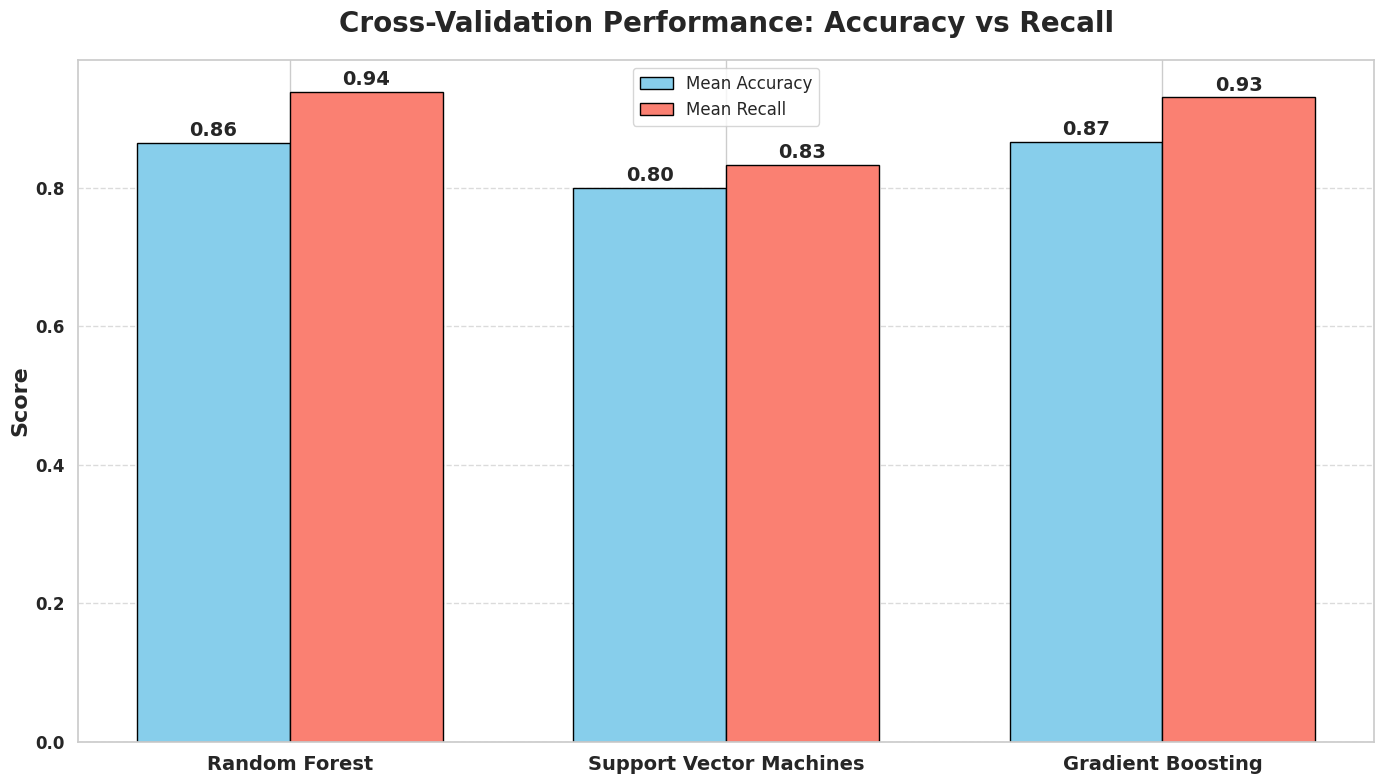

In [40]:
import matplotlib.pyplot as plt

# Plotting the results
plt.figure(figsize=(14, 8))
x = np.arange(len(cv_results_df['Model']))
width = 0.35

# Plot bars for Accuracy and Recall
plt.bar(x - width/2, cv_results_df['Mean Accuracy'], width, label='Mean Accuracy', color='skyblue', edgecolor='black')
plt.bar(x + width/2, cv_results_df['Mean Recall'], width, label='Mean Recall', color='salmon', edgecolor='black')

# Formatting labels and titles (Bold and Large)
plt.xticks(x, cv_results_df['Model'], fontsize=14, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=16, fontweight='bold')
plt.title('Cross-Validation Performance: Accuracy vs Recall', fontsize=20, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for i, row in cv_results_df.iterrows():
    plt.text(i - width/2, row['Mean Accuracy'] + 0.01, f"{row['Mean Accuracy']:.2f}",
             ha='center', fontsize=14, fontweight='bold')
    plt.text(i + width/2, row['Mean Recall'] + 0.01, f"{row['Mean Recall']:.2f}",
             ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# **Implementing Global Explainability (Feature Importance)**
I use my optimized Gradient Boosting model to extract feature importance scores. This visualizes the relative contribution of each feature to the model's final decision.

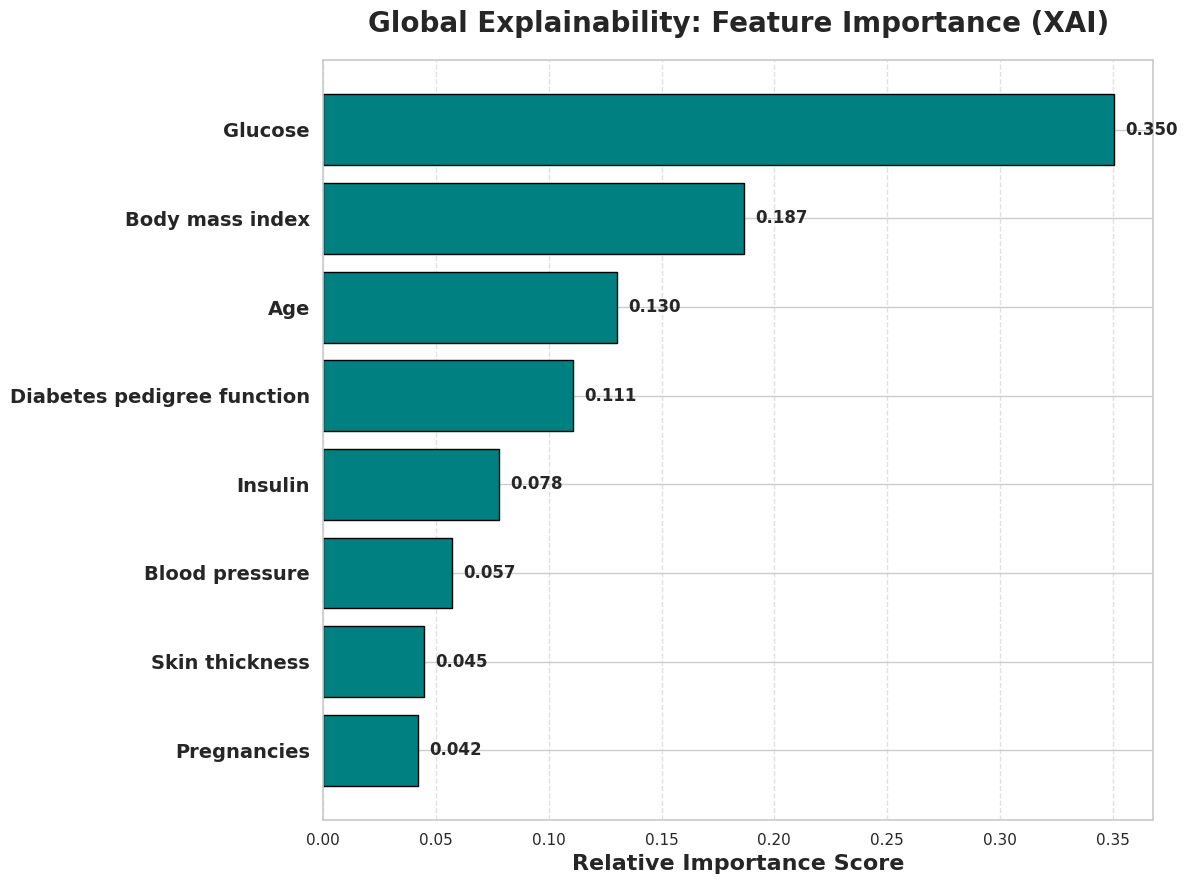

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use the optimized Gradient Boosting model trained on balanced data
gb_model = best_models["Gradient Boosting"]

# 2. Extract feature importance scores
importances = gb_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances) # Sort for visualization

# 3. Plotting the Global Feature Importance
plt.figure(figsize=(12, 9))
plt.title('Global Explainability: Feature Importance (XAI)', fontsize=20, fontweight='bold', pad=20)

# Create horizontal bar chart
plt.barh(range(len(indices)), importances[indices], color='teal', align='center', edgecolor='black')

# Formatting Y-axis with feature names (Bold and Large)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=16, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Adding value labels to the bars
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# **Visualizing the Relationship Between Top Features (Glucose vs BMI)**
In this cell, we plot Glucose levels against BMI, colored by the patient's Outcome. Following your request, all text elements are bolded and the font sizes are increased for maximum clarity.

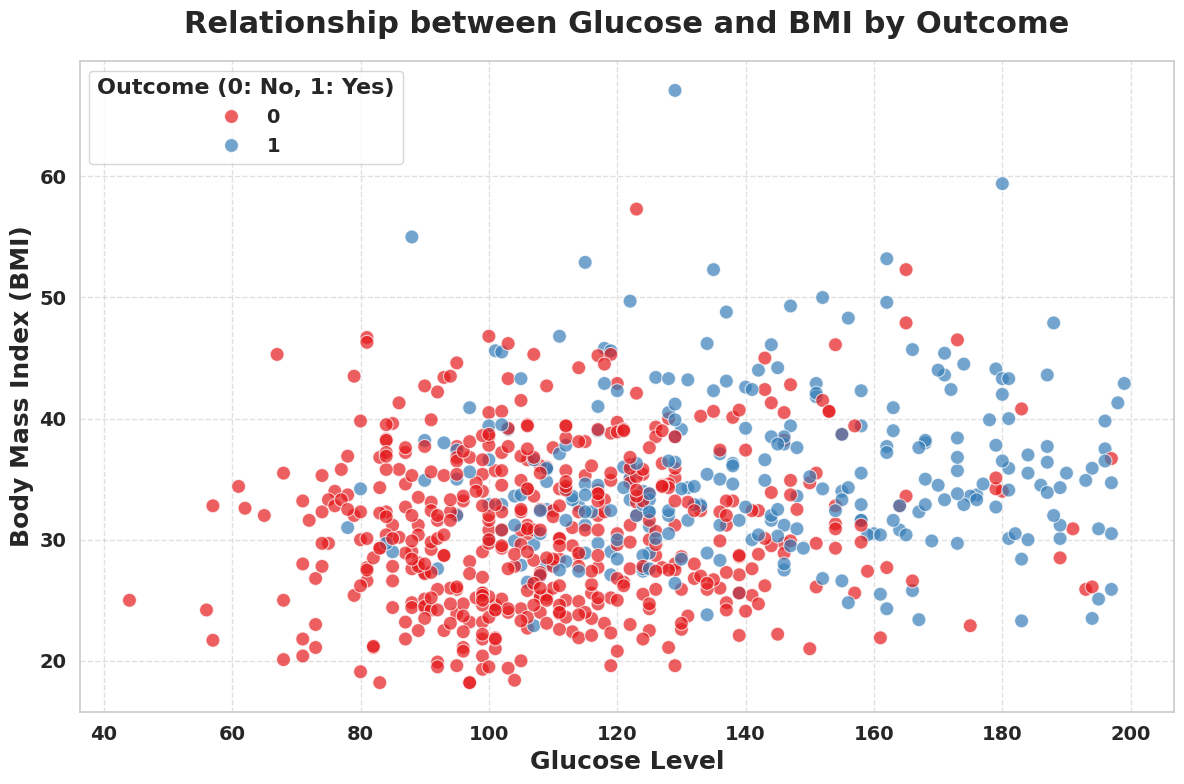

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot for the two highest-impact features
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x='Glucose', y='Body mass index', hue='Outcome',
                          data=df_cleaned, palette='Set1', alpha=0.7, s=100, edgecolor='w')

# Formatting Titles and Labels (Bold and Large)
plt.title('Relationship between Glucose and BMI by Outcome', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Glucose Level', fontsize=18, fontweight='bold')
plt.ylabel('Body Mass Index (BMI)', fontsize=18, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# Legend styling
legend = plt.legend(title='Outcome (0: No, 1: Yes)', fontsize=14, title_fontsize=16, loc='upper left')
plt.setp(legend.get_title(), fontweight='bold')
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()